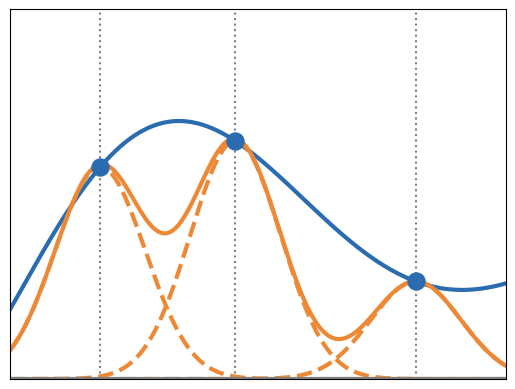

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Approximation target function
def target_function(x):
    return np.sin(x) * np.exp(-0.2 * x) + 1

# Create a wider range of x values with specified axis limits
x = np.linspace(-0.5, 5, 400)

# Create y values for the target function
y_target = target_function(x)

# Define points for Gaussian kernels and their corresponding true function values
points = [0.5, 2.0, 4.0]
y_points = target_function(np.array(points))
h = 0.5  # Bandwidth for Gaussian kernels

# Gaussian kernel function
def gaussian_kernel(x, mu, h):
    return np.exp(-((x - mu)**2) / (2 * h**2))

# Create y values for the scaled Gaussian kernels
scaled_gaussians = [y_points[i] * gaussian_kernel(x, points[i], h) for i in range(len(points))]

# Sum of the Gaussian functions
gaussian_sum = np.sum(scaled_gaussians, axis=0)

# Define the colors
blue_color_hex = '#2B6CB0'  # Example hex code for blue color from the image
orange_color_hex = '#ED8936'  # Example hex code for orange color from the image

# Plot the target function
plt.plot(x, y_target, color=blue_color_hex, linewidth=3)

# Plot the scaled Gaussian kernels
for i, p in enumerate(points):
    plt.plot(x, scaled_gaussians[i], linestyle='dashed', color=orange_color_hex, linewidth=3)

# Plot the sum of the Gaussian functions
plt.plot(x, gaussian_sum, color=orange_color_hex, linewidth=3)

# Mark the points where Gaussian kernels are placed
for i, p in enumerate(points):
    plt.axvline(x=p, linestyle='dotted', color='gray')
    plt.scatter(p, y_points[i], color=blue_color_hex, s=150, marker='o', zorder=5)  # Increase scatter point size and bring to front

# Adjust axis
plt.ylim(0, 2.5)
plt.xlim(-0.5, 5)
plt.axhline(y=0, color='gray', linestyle='-', linewidth=3)

# Remove axis labels and ticks
plt.gca().set_xlabel('')
plt.gca().set_ylabel('')
plt.gca().set_xticks([])
plt.gca().set_yticks([])

plt.show()

100%|██████████| 9464212/9464212 [00:29<00:00, 319660.25it/s]


Extracting ./data/omniglot-py/images_background.zip to ./data/omniglot-py


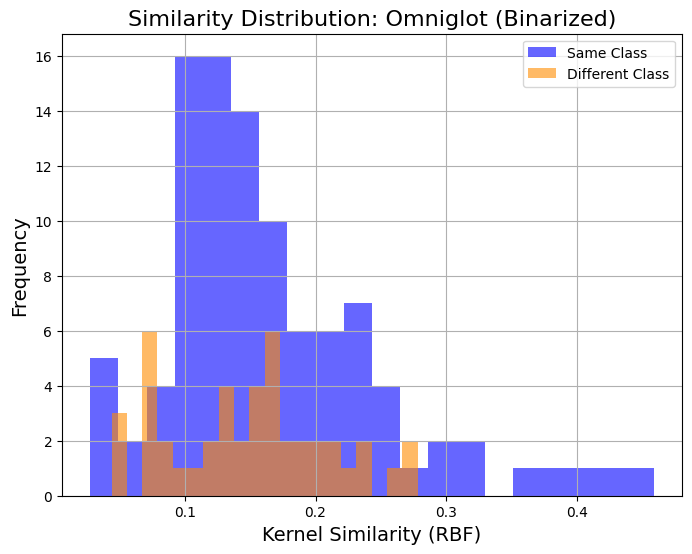

In [1]:
# ----------------------------------------
# Color Palette
# ----------------------------------------
color_palette = {
    "white": "#FFFFFF",
    "light_gray": "#D3D3D3",
    "gray": "#808080",
    "black": "#000000",
    "green": "#008000",
    "blue": "#0000FF",
    "light_blue": "#ADD8E6",
    "light_light_blue": "#E0FFFF",
    "yellow": "#FFFF00",
    "orange": "#FFA500",
    "dark_orange": "#FF8C00",
    "purple": "#800080",
}

# ----------------------------------------
# Imports & Seed Fixing
# ----------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
import random

np.random.seed(0)
torch.manual_seed(0)
random.seed(0)

# ----------------------------------------
# Load Omniglot (Background set)
# ----------------------------------------
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float()),  # Binarize
])

dataset = datasets.Omniglot(
    root="./data",
    background=True,
    download=True,
    transform=transform
)

# ----------------------------------------
# Select N classes with M samples each
# ----------------------------------------
from collections import defaultdict

N = 10  # classes
M = 5   # samples per class
class_images = defaultdict(list)

for img, target in dataset:
    if len(class_images[target]) < M:
        class_images[target].append(img.view(-1))  # Flattened
    if len(class_images) >= N and all(len(v) >= M for v in class_images.values()):
        break

# ----------------------------------------
# Create Positive (same-class) and Negative (diff-class) pairs
# ----------------------------------------
positive_pairs = []
negative_pairs = []

class_list = list(class_images.keys())

for cls in class_list:
    imgs = class_images[cls]
    for i in range(len(imgs)):
        for j in range(i + 1, len(imgs)):
            positive_pairs.append((imgs[i], imgs[j]))

for i in range(len(class_list)):
    for j in range(i + 1, len(class_list)):
        img1 = random.choice(class_images[class_list[i]])
        img2 = random.choice(class_images[class_list[j]])
        negative_pairs.append((img1, img2))

# ----------------------------------------
# Kernel Function: RBF
# ----------------------------------------
def rbf_kernel(x, y, sigma=5.0):
    diff = x - y
    return torch.exp(-torch.sum(diff ** 2) / (2 * sigma ** 2))

# ----------------------------------------
# Compute similarities
# ----------------------------------------
pos_sims = [rbf_kernel(x, y).item() for x, y in positive_pairs]
neg_sims = [rbf_kernel(x, y).item() for x, y in negative_pairs]

# ----------------------------------------
# Plot Histograms
# ----------------------------------------
plt.figure(figsize=(8, 6))
plt.hist(pos_sims, bins=20, alpha=0.6, label="Same Class", color=color_palette["blue"])
plt.hist(neg_sims, bins=20, alpha=0.6, label="Different Class", color=color_palette["dark_orange"])
plt.xlabel("Kernel Similarity (RBF)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Similarity Distribution: Omniglot (Binarized)", fontsize=16)
plt.legend()
plt.grid(True)
plt.show()


## カーネル法の自由度
カーネル法では訓練データ点ごとに1つずつパラメーターを持つため、一見してあまりに自由度が高く、過適合しやすいと考えられる。
これは正しいが、正則化が本質的に重要になる。Representer theorem により、正則化項があれば、

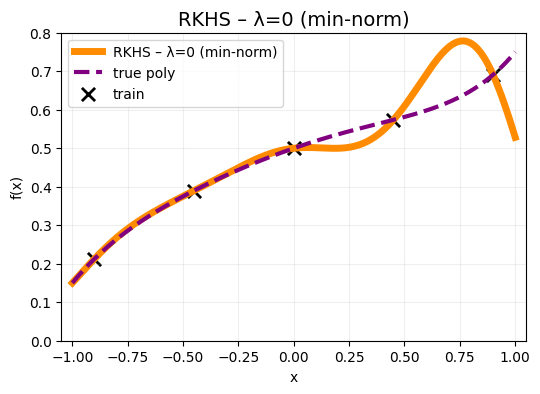

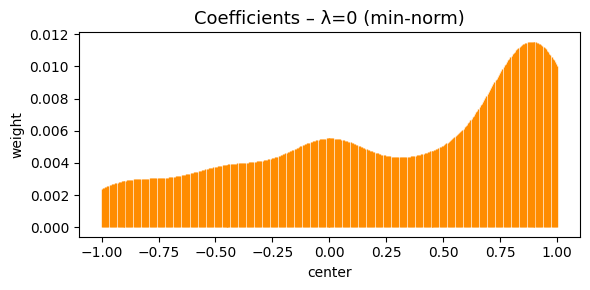

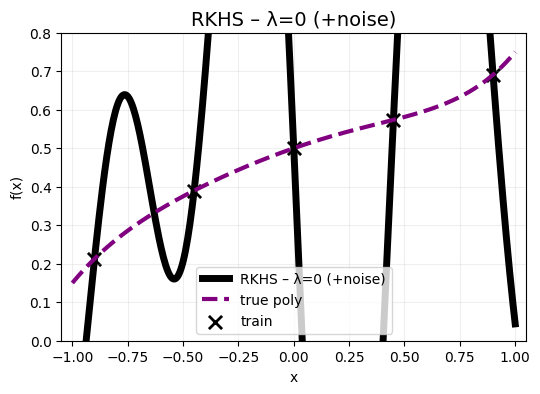

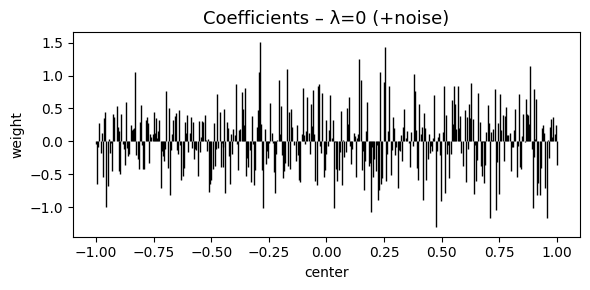

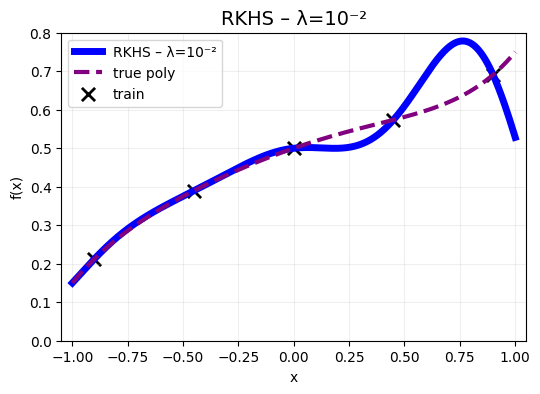

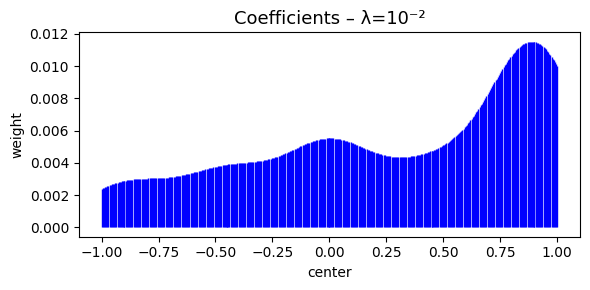

In [ ]:
# -----------------------------------------
# RKHS Representer Theorem Demo (three figures)
# -----------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# ---------- Color Palette ----------
COLOR = {
    "white": "#FFFFFF", "black": "#000000",
    "dark_orange": "#FF8C00", "blue": "#0000FF",
    "purple": "#800080"
}

# ---------- 1. Data ----------
np.random.seed(0)
x_train = np.linspace(-0.9, 0.9, 5)
poly    = np.poly1d([0.1, 0.05, 0.0, -0.1, 0.2, 0.5])
y_train = poly(x_train)

x_grid  = np.linspace(-1.0, 1.0, 400)
centers = np.sort(np.unique(np.concatenate([x_grid, x_train])))

# ---------- 2. Utils ----------
def rbf_kernel(x, c, h):
    return np.exp(-((x[..., None] - c[None, :]) ** 2) / (2 * h**2))

def null_space_basis(A):
    Q, _ = np.linalg.qr(A.T, mode="complete")
    return Q[:, A.shape[0]:]

# ---------- 3. sklearn-like model ----------
class KernelRidge1D:
    def __init__(self, lam=0.0, h=0.5, noise_magnitude=0.0, random_state=None):
        self.lam, self.h, self.noise_magnitude = lam, h, noise_magnitude
        self.rng = np.random.default_rng(random_state)

    def fit(self, X, y, centers):
        self.centers_ = centers
        Phi = rbf_kernel(X, centers, self.h)
        M   = Phi.shape[1]

        if self.lam == 0:
            w_pinv = np.linalg.pinv(Phi) @ y
            if self.noise_magnitude == 0:
                self.coef_ = w_pinv
            else:
                N = null_space_basis(Phi)
                z = self.noise_magnitude * self.rng.standard_normal(N.shape[1])
                self.coef_ = w_pinv + N @ z
        else:
            self.coef_ = np.linalg.solve(
                Phi.T @ Phi + self.lam * np.eye(M),
                Phi.T @ y
            )
        return self

    def predict(self, X):
        Phi = rbf_kernel(np.asarray(X), self.centers_, self.h)
        return Phi @ self.coef_

# ---------- 4. plotting ----------
def plot_single(pred, title, color):
    fig = plt.figure(figsize=(6, 4), facecolor=COLOR["white"])
    ax  = fig.add_subplot(111)
    ax.plot(x_grid, pred, color=color, linewidth=5, label=title)
    ax.plot(x_grid, poly(x_grid), "--", color=COLOR["purple"], lw=3, label="true poly")
    ax.scatter(x_train, y_train, marker="x", s=90, lw=2, color=COLOR["black"], label="train")
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("x"); ax.set_ylabel("f(x)"); ax.set_xlim(-1.05, 1.05)
    plt.ylim(0.0, 0.8)
    ax.grid(alpha=0.2); ax.legend()
    plt.show()

# ----------- 4-B. Coefficient magnitudes (optional) -----------
def plot_coef(coef, title, color):
    fig = plt.figure(figsize=(6, 3), facecolor=COLOR["white"])
    ax  = fig.add_subplot(111)
    ax.vlines(centers, 0, coef, color=color, linewidth=1)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("center"); ax.set_ylabel("weight")
    plt.tight_layout(); plt.show()


# ---------- Experiment ----------
models = {
    "λ=0 (min-norm)": KernelRidge1D(lam=0, h=0.2, noise_magnitude=0,   random_state=42),
    "λ=0 (+noise)":   KernelRidge1D(lam=0, h=0.2, noise_magnitude=0.5, random_state=42),
    "λ=10⁻²":        KernelRidge1D(lam=1e-2, h=0.2, noise_magnitude=0, random_state=42)
}

for m in models.values():
    m.fit(x_train, y_train, centers)

plot_single(models["λ=0 (min-norm)"].predict(x_grid),
            "RKHS – λ=0 (min-norm)", COLOR["dark_orange"])
plot_coef(models["λ=0 (min-norm)"].coef_,
          "Coefficients – λ=0 (min-norm)", COLOR["dark_orange"])

plot_single(models["λ=0 (+noise)"].predict(x_grid),
            "RKHS – λ=0 (+noise)", COLOR["black"])
plot_coef(models["λ=0 (+noise)"].coef_,
          "Coefficients – λ=0 (+noise)", COLOR["black"])

plot_single(models["λ=10⁻²"].predict(x_grid),
            "RKHS – λ=10⁻²", COLOR["blue"])
plot_coef(models["λ=10⁻²"].coef_,
          "Coefficients – λ=10⁻²", COLOR["blue"])